In [2]:
import os 
import sys

running_path = "/Odyssey/private/o23gauvr/code/"
os.chdir(running_path)
sys.path.insert(0,running_path)

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl

import pickle

import torch
import torch.nn as nn
import numpy as np
from scipy.signal import butter, filtfilt

from FASCINATION.src.utils import unorm_ssp_arr_3D

from FASCINATION.src.utils import unorm_ssp_arr_3D, get_cfg_from_ckpt_path, load_model

from sklearn.decomposition import PCA


from tqdm import tqdm

from pathlib import Path

from MLIC.MLIC.models import MLICPlusPlus
from MLIC.MLIC.utils.utils import Config

import pandas as pd
import xarray as xr

import math


In [4]:
import scienceplots
#plt.style.use('science')
plt.style.use(['science','ieee'])
plt.rcParams.update({'figure.dpi': '100'}) #if IEEE and plt.show is used

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [6]:

def process_model_in_batches(model, data_tensor, batch_size=4, dim=0, device='cuda'):
    """
    Process large tensors through model in batches to avoid OOM.
    
    Args:
        model: PyTorch model
        data_tensor: Input tensor
        batch_size: Number of samples per batch
        dim: Dimension along which to batch (0=time, 2=lat, 3=lon)
        device: Device to use
        
    Returns:
        numpy array of model outputs concatenated
    """
    results = []
    n_samples = data_tensor.shape[dim]
    
    with torch.no_grad():
        for i in tqdm(range(0, n_samples, batch_size), desc="Processing batches"):
            end_idx = min(i + batch_size, n_samples)
            
            # Create slice for the batch
            slices = [slice(None)] * len(data_tensor.shape)
            slices[dim] = slice(i, end_idx)
            
            batch_data = data_tensor[tuple(slices)]
            batch_output = model(batch_data).detach().cpu().numpy()
            results.append(batch_output)
    
    # Concatenate along the same dimension
    output = np.concatenate(results, axis=dim)
    return output

In [7]:


def reorder_rowwise(flat_list, ncol):
    return sum((flat_list[i::ncol] for i in range(ncol)), [])

def custom_label_sort(label):
    if label == "PCA":
        return (0, 0)
    elif label.startswith("PCA pooled by factor "):
        # Extract the pooling factor (e.g., 2, 4, 8, 16)
        factor = int(label.split("factor ")[1].split("x")[0])
        return (1, factor)
    elif label == "rgb mlic++":
        return (2, 0)
    elif label == "ssp mlic++":
        return (3, 0)
    else:
        return (99, label)  # fallback for unknown labels



In [8]:

def apply_pooling_upsample_to_pca(pca_ae: np.ndarray, ssp_truth_shape: tuple, n_layer_pooling: int, pooling_mode: str = "mean") -> np.ndarray:
    """
    Apply spatial pooling and upsampling to PCA-transformed data using numpy/scipy, then inverse transform.
    Works entirely with numpy arrays using skimage.measure.block_reduce and scipy.interpolate.RectBivariateSpline.
    
    Args:
        pca_ae: flattened PCA-transformed array with shape (batch*lat*lon, n_components)
        ssp_truth_shape: tuple of original spatial shape (batch, depth, lat, lon)
        n_layer_pooling: number of pooling layers to apply (e.g., 3)
        pca: fitted PCA object with inverse_transform method
        pooling_mode: "mean" for average pooling or "max" for max pooling
        
    Returns:
        reconstructed: data in shape (batch, depth, lat, lon) after pooling/upsampling and inverse transform
    """
    from skimage.measure import block_reduce
    from scipy.interpolate import RectBivariateSpline
    
    batch, depth, lat, lon = ssp_truth_shape
    n_components = pca_ae.shape[1]
    
    # Reshape from (batch*lat*lon, n_components) to (batch, lat, lon, n_components)
    pca_ae_reshaped = pca_ae.reshape(batch, lat, lon, n_components)
    
    # Transpose to (batch, n_components, lat, lon) for spatial pooling
    pca_ae_spatial = pca_ae_reshaped.transpose(0, 3, 1, 2)  # (batch, n_components, lat, lon)
    
    # Apply pooling and upsampling for each batch and component
    pooled_upsampled_list = []
    
    for b in range(batch):
        component_list = []
        for c in range(n_components):
            data_2d = pca_ae_spatial[b, c, :, :]  # (lat, lon)
            
            # Apply pooling layers
            pooled_data = data_2d.copy()
            for _ in range(n_layer_pooling):
                block_size = 2
                if pooling_mode == "mean":
                    pooled_data = block_reduce(pooled_data, block_size=(block_size, block_size), func=np.mean)
                else:  # max
                    pooled_data = block_reduce(pooled_data, block_size=(block_size, block_size), func=np.max)
            
            # Upsample back to original size using RectBivariateSpline
            pooled_h, pooled_w = pooled_data.shape

            
            # Create coordinate arrays for the pooled data
            y_old = np.arange(pooled_h)
            x_old = np.arange(pooled_w)
            
            # Create RectBivariateSpline interpolator (cubic by default, kx=ky=3)
            spl = RectBivariateSpline(y_old, x_old, pooled_data, kx=min(3, pooled_data.shape[0]-1), ky=min(3, pooled_data.shape[1]-1))
            
            # Create new coordinate arrays for upsampled data
            y_new = np.linspace(0, pooled_h - 1, lat)
            x_new = np.linspace(0, pooled_w - 1, lon)
            
            # Interpolate to original size
            upsampled_data = spl(y_new, x_new, grid=True)
            
            component_list.append(upsampled_data)
        
        # Stack components and convert to (n_components, lat, lon)
        pooled_upsampled_list.append(np.array(component_list))
    
    # Concatenate batches: (batch, n_components, lat, lon)
    pooled_upsampled_np = np.array(pooled_upsampled_list)
    
    # Reshape to flattened form (batch*lat*lon, n_components) for inverse transform
    pooled_upsampled_flat = pooled_upsampled_np.transpose(0, 2, 3, 1).reshape(-1, n_components)
    
    return pooled_upsampled_flat


In [9]:

def cr_to_memory_size(cr):
    """Convert compression rate to memory size with units (Gb, Mb, Kb, bytes)"""
    memory_go = 46.9 / cr
    if memory_go >= 1:
        return f"{memory_go:.1f} Gb"
    else:
        memory_mo = memory_go * 1024
        if memory_mo >= 1:
            return f"{memory_mo:.0f} Mb"
        else:
            memory_ko = memory_mo * 1024
            if memory_ko >= 1:
                return f"{memory_ko:.0f} Kb"
            else:
                memory_octets = memory_ko * 1024
                return f"{memory_octets:.0f} bytes"
            



In [10]:

def parse_experiment_config(ckpt_path):
    """
    Parse experiment_config.log file to extract N and M values.
    
    Args:
        ckpt_path (str): PosixPath to checkpoint 
        
    Returns:
        tuple: (N, M) values or (None, None) if parsing fails
    """

    config_file = list((ckpt_path.parent.parent).rglob("train_*.log")) 
    if not config_file:
        print(f"Warning: train logs not found in {ckpt_path}")
        return None, None
    
    config_file = config_file[0]  # Get the first match if multiple found

    try:
        with open(config_file, 'r') as f:
            content = f.read()
        
        # Extract N and M values from MODEL CONFIGURATION section
        N, M = None, None
        
        lines = content.split('\n')

        cfg = eval((lines[1].strip().split("INFO: ")[-1]).replace("<class 'torch.nn.modules.activation.","nn.").replace("'>",""))


        return cfg
        
            
    except Exception as e:
        print(f"Error parsing config file in {ckpt_path}: {e}")
        return None


In [11]:

def compute_total_bits(out_net) -> float:
    return sum(torch.log(likelihoods).sum() / (-math.log(2)) for likelihoods in out_net['likelihoods'].values()).item()


In [12]:

def get_rmse_df_deciles(rmse_da: xr.DataArray,  metric_type: str = "SSP") -> pd.DataFrame:

    # Flatten rmse_z and get valid (non-NaN) values with indices
    rmse_flat = rmse_da.values.ravel()
    valid_mask = np.isfinite(rmse_flat)
    valid_values = rmse_flat[valid_mask]
    valid_indices = np.where(valid_mask)[0]

    # Compute 10 decile thresholds: 0%, 11.1%, 22.2%, ..., 100%
    percentiles = np.linspace(0, 100, 41)
    thresholds = np.percentile(valid_values, percentiles)

    # For each threshold, find the closest actual data point
    selected_flat_indices = []
    for thresh in thresholds:
        idx_in_valid = np.argmin(np.abs(valid_values - thresh))
        selected_flat_indices.append(valid_indices[idx_in_valid])

    # Convert flat indices back to multi-dimensional coordinates
    shape = rmse_da.shape
    dim_names = rmse_da.dims
    selected_points = []

    for i, flat_idx in enumerate(selected_flat_indices):
        multi_idx = np.unravel_index(flat_idx, shape)
        point = {dim: int(idx) for dim, idx in zip(dim_names, multi_idx)}  # integer indices
        point['rmse_value'] = rmse_flat[flat_idx]
        point['percentile'] = percentiles[i]
        selected_points.append(point)

    # Display results
    df_deciles = pd.DataFrame(selected_points)

    fig = plt.figure(figsize=(10, 6))
    plt.bar(df_deciles['percentile'], df_deciles['rmse_value'], width=3)
    plt.title(f'RMSE at Selected Percentiles ({metric_type})')
    plt.xlabel('Percentile')
    plt.ylabel('RMSE')
    plt.grid()
    plt.show()

    return df_deciles

In [13]:
def filter_pareto_front(data_dict, metric_name, direction='min'):
    """
    Extract metric and CR values, filtered to Pareto front.
    
    Args:
        data_dict: Your nested dictionary with CR as keys
        metric_name: The metric to extract (e.g., "RMSE", "F1_score")
        direction: 'min' for lower is better (RMSE, MAE, PSNR), 
                   'max' for higher is better (F1_score, R2_score, MS-SSIM)
    
    Returns:
        cr_list, metric_list: Filtered lists on the Pareto front
    """
    # Extract all points
    points = [(float(cr), float(data_dict[cr][metric_name])) 
              for cr in data_dict.keys()]
    
    # Filter Pareto front
    pareto_points = []
    for cr, metric in points:
        is_dominated = False
        for other_cr, other_metric in points:
            if direction == 'min':
                # For minimization: dominated if other has higher CR and lower metric
                if other_cr > cr and other_metric < metric:
                    is_dominated = True
                    break
            else:  # 'max'
                # For maximization: dominated if other has higher CR and higher metric
                if other_cr > cr and other_metric > metric:
                    is_dominated = True
                    break
        if not is_dominated:
            pareto_points.append((cr, metric))
    
    # Sort by CR for clarity
    pareto_points.sort()
    cr_list, metric_list = zip(*pareto_points) if pareto_points else ([], [])
    
    return np.array(cr_list), np.array(metric_list)




In [14]:
def filter_pareto_front_new(data_dict,metric_name, type="SSP", direction='min'): #type["SSP","GRAD"]
    """
    Extract metric and CR values, filtered to Pareto front.
    
    Args:
        data_dict: Your nested dictionary with CR as keys
        metric_name: The metric to extract (e.g., "RMSE", "F1_score")
        direction: 'min' for lower is better (RMSE, MAE, PSNR), 
                   'max' for higher is better (F1_score, R2_score, MS-SSIM)
    
    Returns:
        cr_list, metric_list: Filtered lists on the Pareto front
    """
    # Extract all points
    points = [(float(cr), float(data_dict[cr][type][metric_name])) 
              for cr in data_dict.keys()]
    
    # Filter Pareto front
    pareto_points = []
    for cr, metric in points:
        is_dominated = False
        for other_cr, other_metric in points:
            if direction == 'min':
                # For minimization: dominated if other has higher CR and lower metric
                if other_cr > cr and other_metric < metric:
                    is_dominated = True
                    break
            else:  # 'max'
                # For maximization: dominated if other has higher CR and higher metric
                if other_cr > cr and other_metric > metric:
                    is_dominated = True
                    break
        if not is_dominated:
            pareto_points.append((cr, metric))
    
    # Sort by CR for clarity
    pareto_points.sort()
    cr_list, metric_list = zip(*pareto_points) if pareto_points else ([], [])
    
    return np.array(cr_list), np.array(metric_list)



In [15]:
def find_closest_key(keys_list, n):
    """Find the closest key to integer n"""
    return min(keys_list, key=lambda x: abs(x - n))

# Load data

In [16]:
data_type = "enatl_natl"

In [17]:
with open(f"/Odyssey/private/o23gauvr/code/FASCINATION/pickle/model_metrics_mlic.pkl", "rb") as f:
    model_metrics_mlic = pickle.load(f)
with open(f"/Odyssey/private/o23gauvr/code/FASCINATION/pickle/model_metrics_cae_articles_norm_test.pkl", "rb") as f:   #/Odyssey/private/o23gauvr/code/FASCINATION/pickle/model_metrics_cae_full.pkl
    model_metrics_cae = pickle.load(f)
with open(f"/Odyssey/private/o23gauvr/code/FASCINATION/pickle/model_metrics_pca.pkl", "rb") as f:
    model_metrics_pca = pickle.load(f)
with open(f"/Odyssey/private/o23gauvr/code/FASCINATION/pickle/model_metrics_mlic_original.pkl", "rb") as f:
    model_metrics_mlic_original = pickle.load(f)


In [20]:
with open(f"/Odyssey/private/o23gauvr/code/FASCINATION/pickle/data_dict_mlic.pkl", "rb") as f:
    data_dict_mlic = pickle.load(f)
with open(f"/Odyssey/private/o23gauvr/code/FASCINATION/pickle/data_dict_cae_articles_norm_test.pkl", "rb") as f:
    data_dict_cae = pickle.load(f)
with open(f"/Odyssey/private/o23gauvr/code/FASCINATION/pickle/data_dict_pca.pkl", "rb") as f:
    data_dict_pca = pickle.load(f)


In [21]:
with open(f"/Odyssey/private/o23gauvr/code/FASCINATION/pickle/{data_type}_dm_157_196_256_norm_per_split.pkl", "rb") as f:
    dm = pickle.load(f)


# Plots

## Metric/CR

In [22]:
def filter_n_points_display(cr_list, metric_list, cr_max, gap):
    cr_mask = (np.array(cr_list) <= cr_max)
    cr_filtered = np.array(cr_list)[cr_mask]
    metric_filtered = np.array(metric_list)[cr_mask]

    # Keep first, last, and every 3rd point
    indices = list(range(0, len(cr_filtered), gap))
    if indices[-1] != len(cr_filtered) - 1:
        indices.append(len(cr_filtered) - 1)

    cae_cr = cr_filtered[indices]
    cae_metric = metric_filtered[indices]

    return cae_cr, cae_metric

In [23]:
model_metrics_pca['PCA'][157.0]

{'RMSE': np.float64(1.017635724679384),
 'PSNR': np.float64(47.97895671415701),
 'MS-SSIM': np.float64(0.8409929454121244),
 'ECS': np.float64(63.37958334996068),
 'MAE': np.float64(0.6790623629062731),
 'mean_error_n_min_max': np.float64(1.8474365431702562),
 'F1_score': np.float64(0.5002785180928468),
 'R2_score': np.float64(0.9953487456982526)}

In [24]:
model_metrics_cae

{'CAE': {502.4: {'SSP': {'rmse': 1.2163220643997192,
    'mae': 0.7778041958808899,
    'psnr': 62.091312179259944,
    'ecs': 40.84004372961259,
    'extremum_pos': 20.20882147834254,
    'f1_score': 0.6166115231019267,
    'pearson': 0.9977935552597046,
    'pearson_pvalue': 3.731026801024339e-34,
    'r2_score': 0.9933508038520813,
    'model_type': 'CAE',
    'checkpoint_path': '/Odyssey/private/o23gauvr/code/FASCINATION/outputs/remote/outputs/eusipco/AE/pred_1_grad_0_max_pos_0_max_value_0_fft_0_weighted_1_inflection_pos_0_inflection_value_0/dense_True/pooling_Avg_on_dim_dense/channels_[5000, 3000, 5]/upsample_mode_trilinear/linear_layer_False/cr_100000/1_conv_per_layer/padding_cubic/interp_size_5/final_upsample_upsample/act_fn_LeakyRelu/use_final_act_fn_False/lr_0.001/normalization_mean_std_along_depth/manage_nan_supress_with_max_depth/2026-02-11_04-18/checkpoints/best_checkpoint_rmse.pth.tar'},
   'GRAD': None},
  31.4: {'SSP': {'rmse': 0.553425133228302,
    'mae': 0.38282689452

In [25]:
sorted(list(model_metrics_mlic['MLIC++ SSP'].keys()))


[1171.4749215656268, 13167.767612842115, 91149.89137897044]

In [26]:
model_metrics_cae['CAE']

{502.4: {'SSP': {'rmse': 1.2163220643997192,
   'mae': 0.7778041958808899,
   'psnr': 62.091312179259944,
   'ecs': 40.84004372961259,
   'extremum_pos': 20.20882147834254,
   'f1_score': 0.6166115231019267,
   'pearson': 0.9977935552597046,
   'pearson_pvalue': 3.731026801024339e-34,
   'r2_score': 0.9933508038520813,
   'model_type': 'CAE',
   'checkpoint_path': '/Odyssey/private/o23gauvr/code/FASCINATION/outputs/remote/outputs/eusipco/AE/pred_1_grad_0_max_pos_0_max_value_0_fft_0_weighted_1_inflection_pos_0_inflection_value_0/dense_True/pooling_Avg_on_dim_dense/channels_[5000, 3000, 5]/upsample_mode_trilinear/linear_layer_False/cr_100000/1_conv_per_layer/padding_cubic/interp_size_5/final_upsample_upsample/act_fn_LeakyRelu/use_final_act_fn_False/lr_0.001/normalization_mean_std_along_depth/manage_nan_supress_with_max_depth/2026-02-11_04-18/checkpoints/best_checkpoint_rmse.pth.tar'},
  'GRAD': None},
 31.4: {'SSP': {'rmse': 0.553425133228302,
   'mae': 0.38282689452171326,
   'psnr': 68

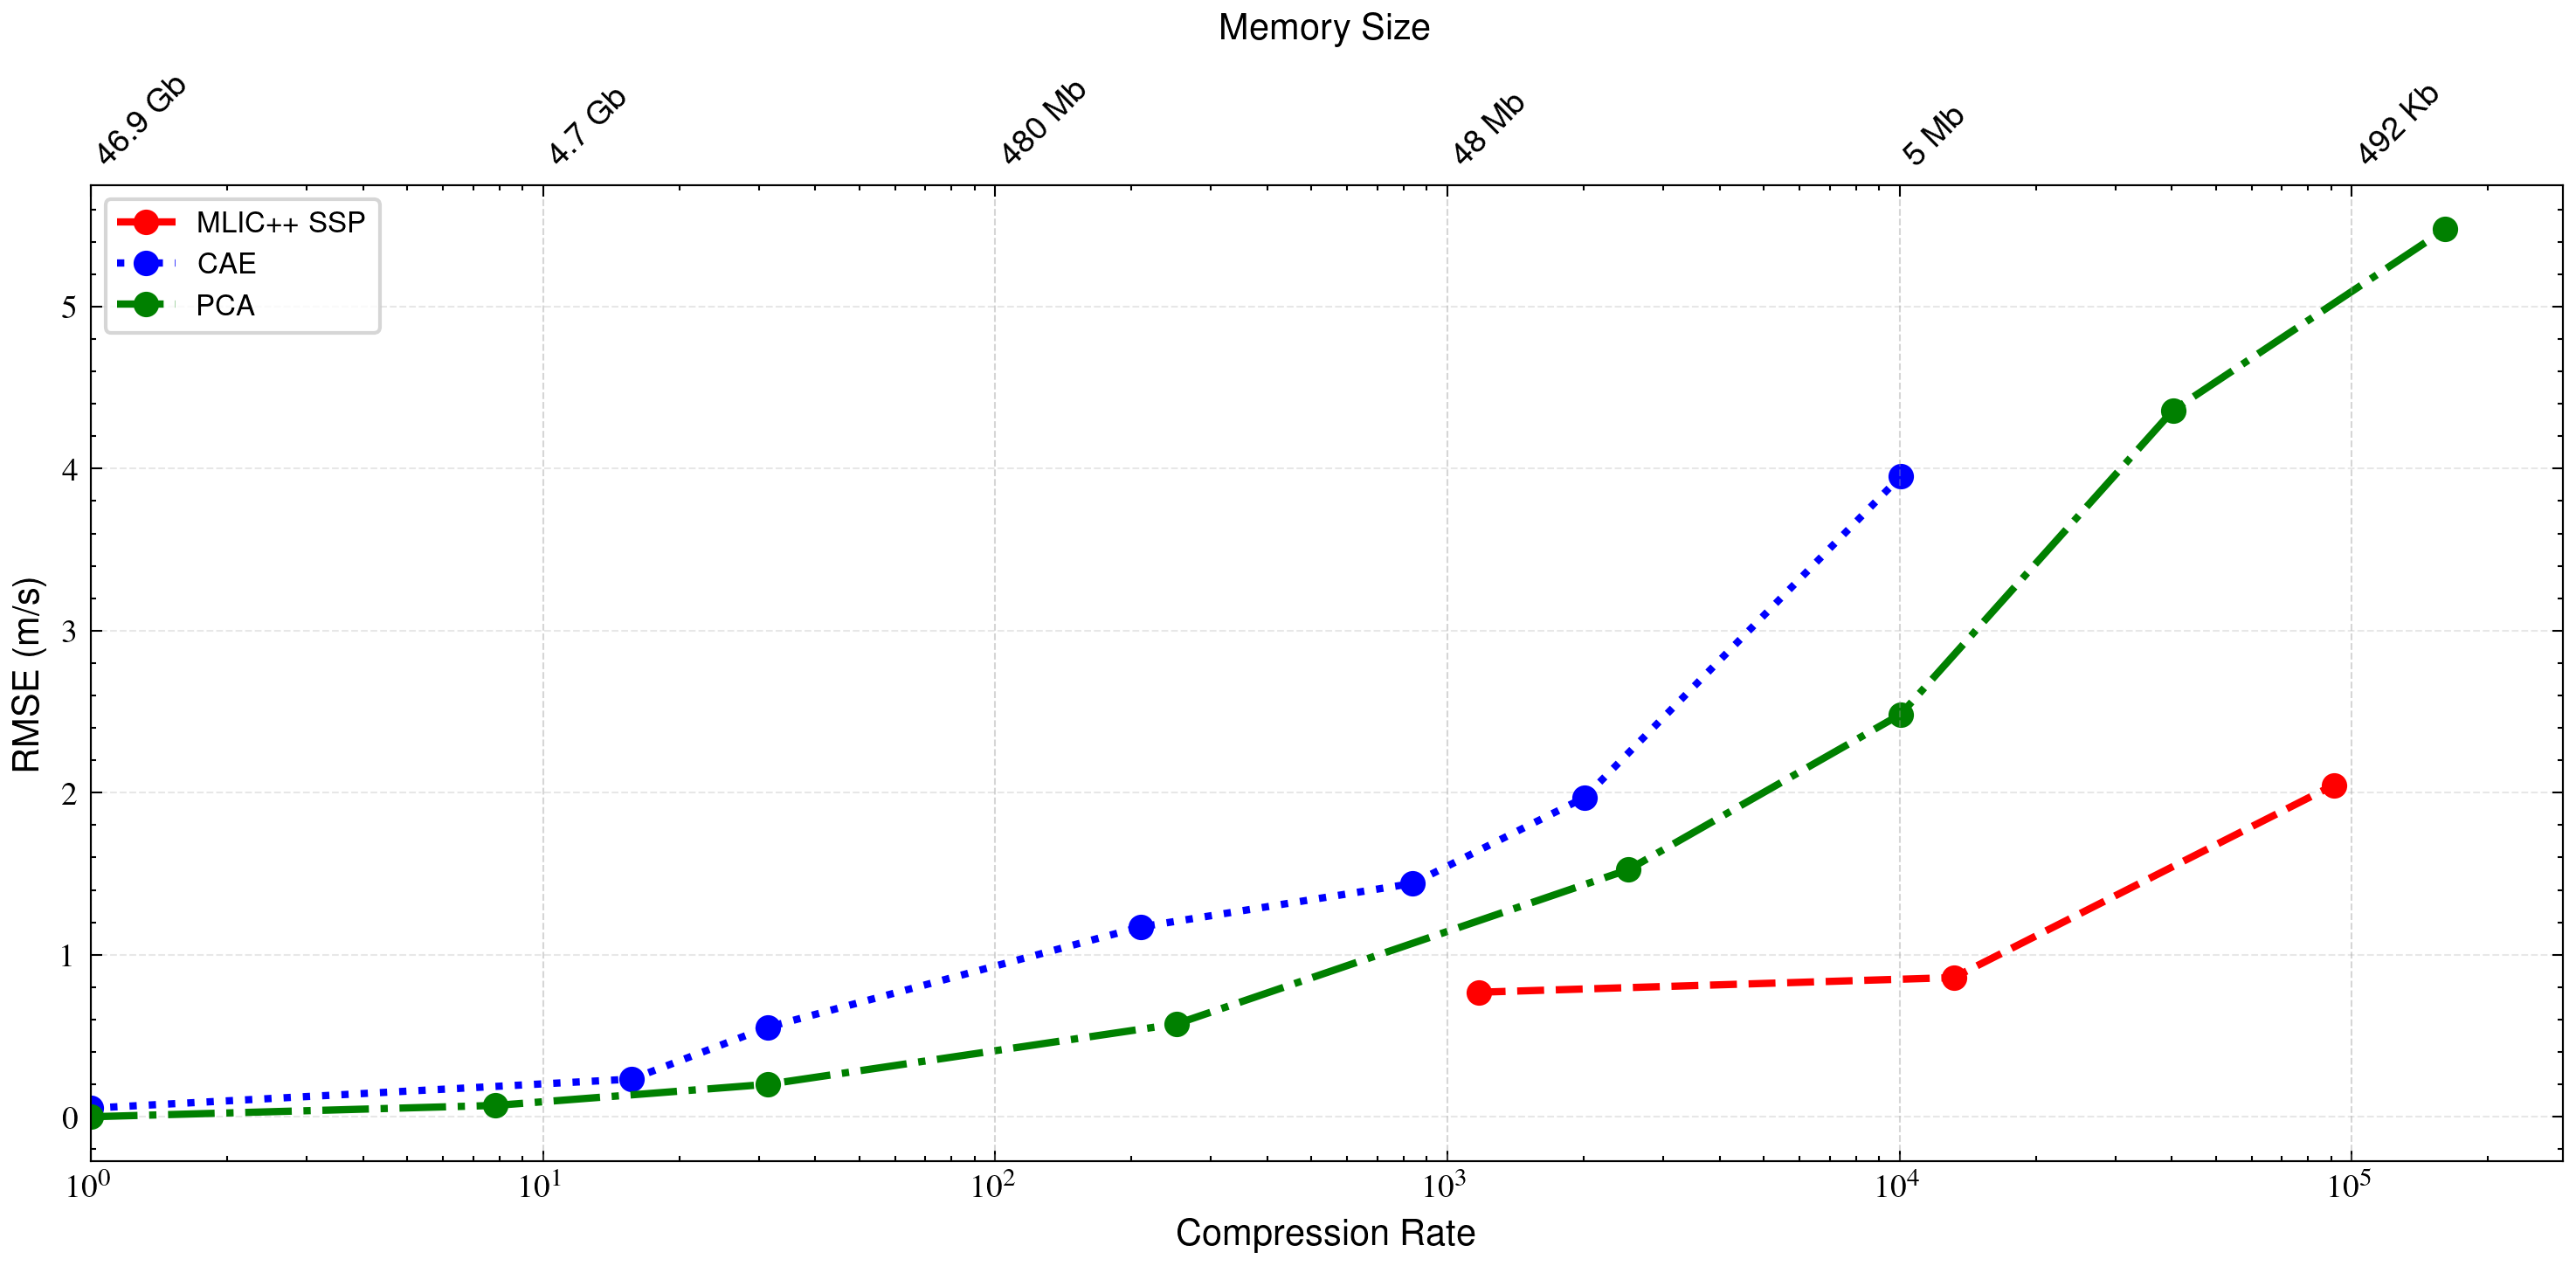

In [53]:

metric = "RMSE"
unit = {"RMSE":"(m/s)",
        "F1_score":"",
        "MS-SSIM": "",
        "R2_score": "",
        "ECS": "(m)"}

pareto_dir = {"RMSE":"min",
              "F1_score":"max",
              "MS-SSIM": "max",
              "R2_score": "max",
              "ECS": "min"}

ieee_rcparams = {
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica'],
        'font.size': 9,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 8,
        'figure.figsize': (8.5, 3.5),
        'figure.dpi': 300,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
        'lines.linewidth': 2,
        'patch.edgecolor': 'none',
        }

mpl.rcParams.update(ieee_rcparams)


colors = plt.rcParams['axes.prop_cycle'].by_key()['color']


# # Define IEEE colors: skip first (black), MLIC=red (2nd), CAE=blue, PCA=green
ieee_model_colors = {
'MLIC': colors[1],  # Red (2nd color in typical matplotlib)
'CAE': colors[2],   # Blue
'PCA': colors[3],   # Green
}

linestyle =   plt.rcParams['axes.prop_cycle'].by_key()['linestyle']

ieee_model_ls = {
'MLIC': linestyle[1],  # 
'CAE': linestyle[2],   # Dhed
'PCA': linestyle[3],   # 
}



fig, ax = plt.subplots(figsize=(10, 5))



pca_cr, pca_metric = filter_pareto_front(model_metrics_pca['PCA'], metric, direction=pareto_dir[metric])
pca_cr, pca_metric = filter_n_points_display(pca_cr,pca_metric,2e5,3)

cae_cr, cae_metric = filter_pareto_front_new(model_metrics_cae['CAE'],metric.lower(),type="SSP", direction=pareto_dir[metric])
cae_cr, cae_metric = filter_n_points_display(cae_cr,cae_metric,2e5,2)
        

#mlic_cr, mlic_metric = filter_pareto_front(model_metrics_mlic['MLIC++ SSP'], metric, direction=pareto_dir[metric])
mlic_cr = sorted(list(model_metrics_mlic['MLIC++ SSP'].keys()))
mlic_metric = [model_metrics_mlic['MLIC++ SSP'][cr][metric] for cr in mlic_cr]

plt.plot(mlic_cr, mlic_metric, marker='o', label='MLIC++ SSP', color=ieee_model_colors['MLIC'], linestyle=ieee_model_ls['MLIC'])
plt.plot(cae_cr, cae_metric, marker='o', label='CAE', color=ieee_model_colors['CAE'], linestyle=ieee_model_ls['CAE'])
plt.plot(pca_cr, pca_metric, marker='o', label='PCA', color=ieee_model_colors['PCA'], linestyle=ieee_model_ls['PCA'])




cr_ticks = np.array(ax.get_xticks())


# after all plotting on ax
ax.set_xscale("log")
ax.set_xlim(left=1)  # optional but usually needed for CR

# force matplotlib to compute final tick locations
ax.figure.canvas.draw()



# title = f"{metric.replace('_', ' ').replace('2', '²')} {unit[metric]} per Compression Rate"
# ax.set_title(title, pad=15)
ax.grid(True)
ax.set_xlabel("Compression Rate",)
ax.set_ylabel(f"{metric.replace('_', ' ').replace('2', '²')} {unit[metric]}")

ax.legend(loc='best',  frameon=True)

cr_ticks = np.array(ax.get_xticks(minor=False))
x0, x1 = ax.get_xlim()
valid = (cr_ticks >= 1) & (cr_ticks >= x0) & (cr_ticks <= x1)

ticks = cr_ticks[valid]
mem_labels = [cr_to_memory_size(t) for t in ticks]

# secondary axis
ax2 = ax.twiny()
ax2.set_xscale("log")
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(ticks)
ax2.set_xticklabels(mem_labels, rotation=45, ha="left")
ax2.set_xlabel("Memory Size",  labelpad=8)
ax2.tick_params(axis="x", which="major")

plt.savefig(f'/Odyssey/private/o23gauvr/code/articles/ICUA/imgs/{metric}_CR.pdf', bbox_inches='tight', dpi=300)

fig.tight_layout()
plt.show()


In [55]:
pca_cr, pca_metric

(array([1.00000e+00, 7.85000e+00, 3.14000e+01, 2.51200e+02, 2.51200e+03,
        1.00480e+04, 4.01920e+04, 1.60768e+05]),
 array([3.69662477e-04, 7.04177469e-02, 2.00874113e-01, 5.72892480e-01,
        1.52559935e+00, 2.48386202e+00, 4.35893124e+00, 5.47623381e+00]))

In [54]:
cae_cr, cae_metric

(array([1.00000000e+00, 1.57000000e+01, 3.14000000e+01, 2.09333333e+02,
        8.37333333e+02, 2.00960000e+03, 1.00480000e+04]),
 array([0.0534824 , 0.23293377, 0.55342513, 1.17142439, 1.44003189,
        1.97062635, 3.95168877]))

In [56]:
mlic_cr, mlic_metric


([1171.4749215656268, 13167.767612842115, 91149.89137897044],
 [0.7688173651695251, 0.8592950701713562, 2.0472941398620605])

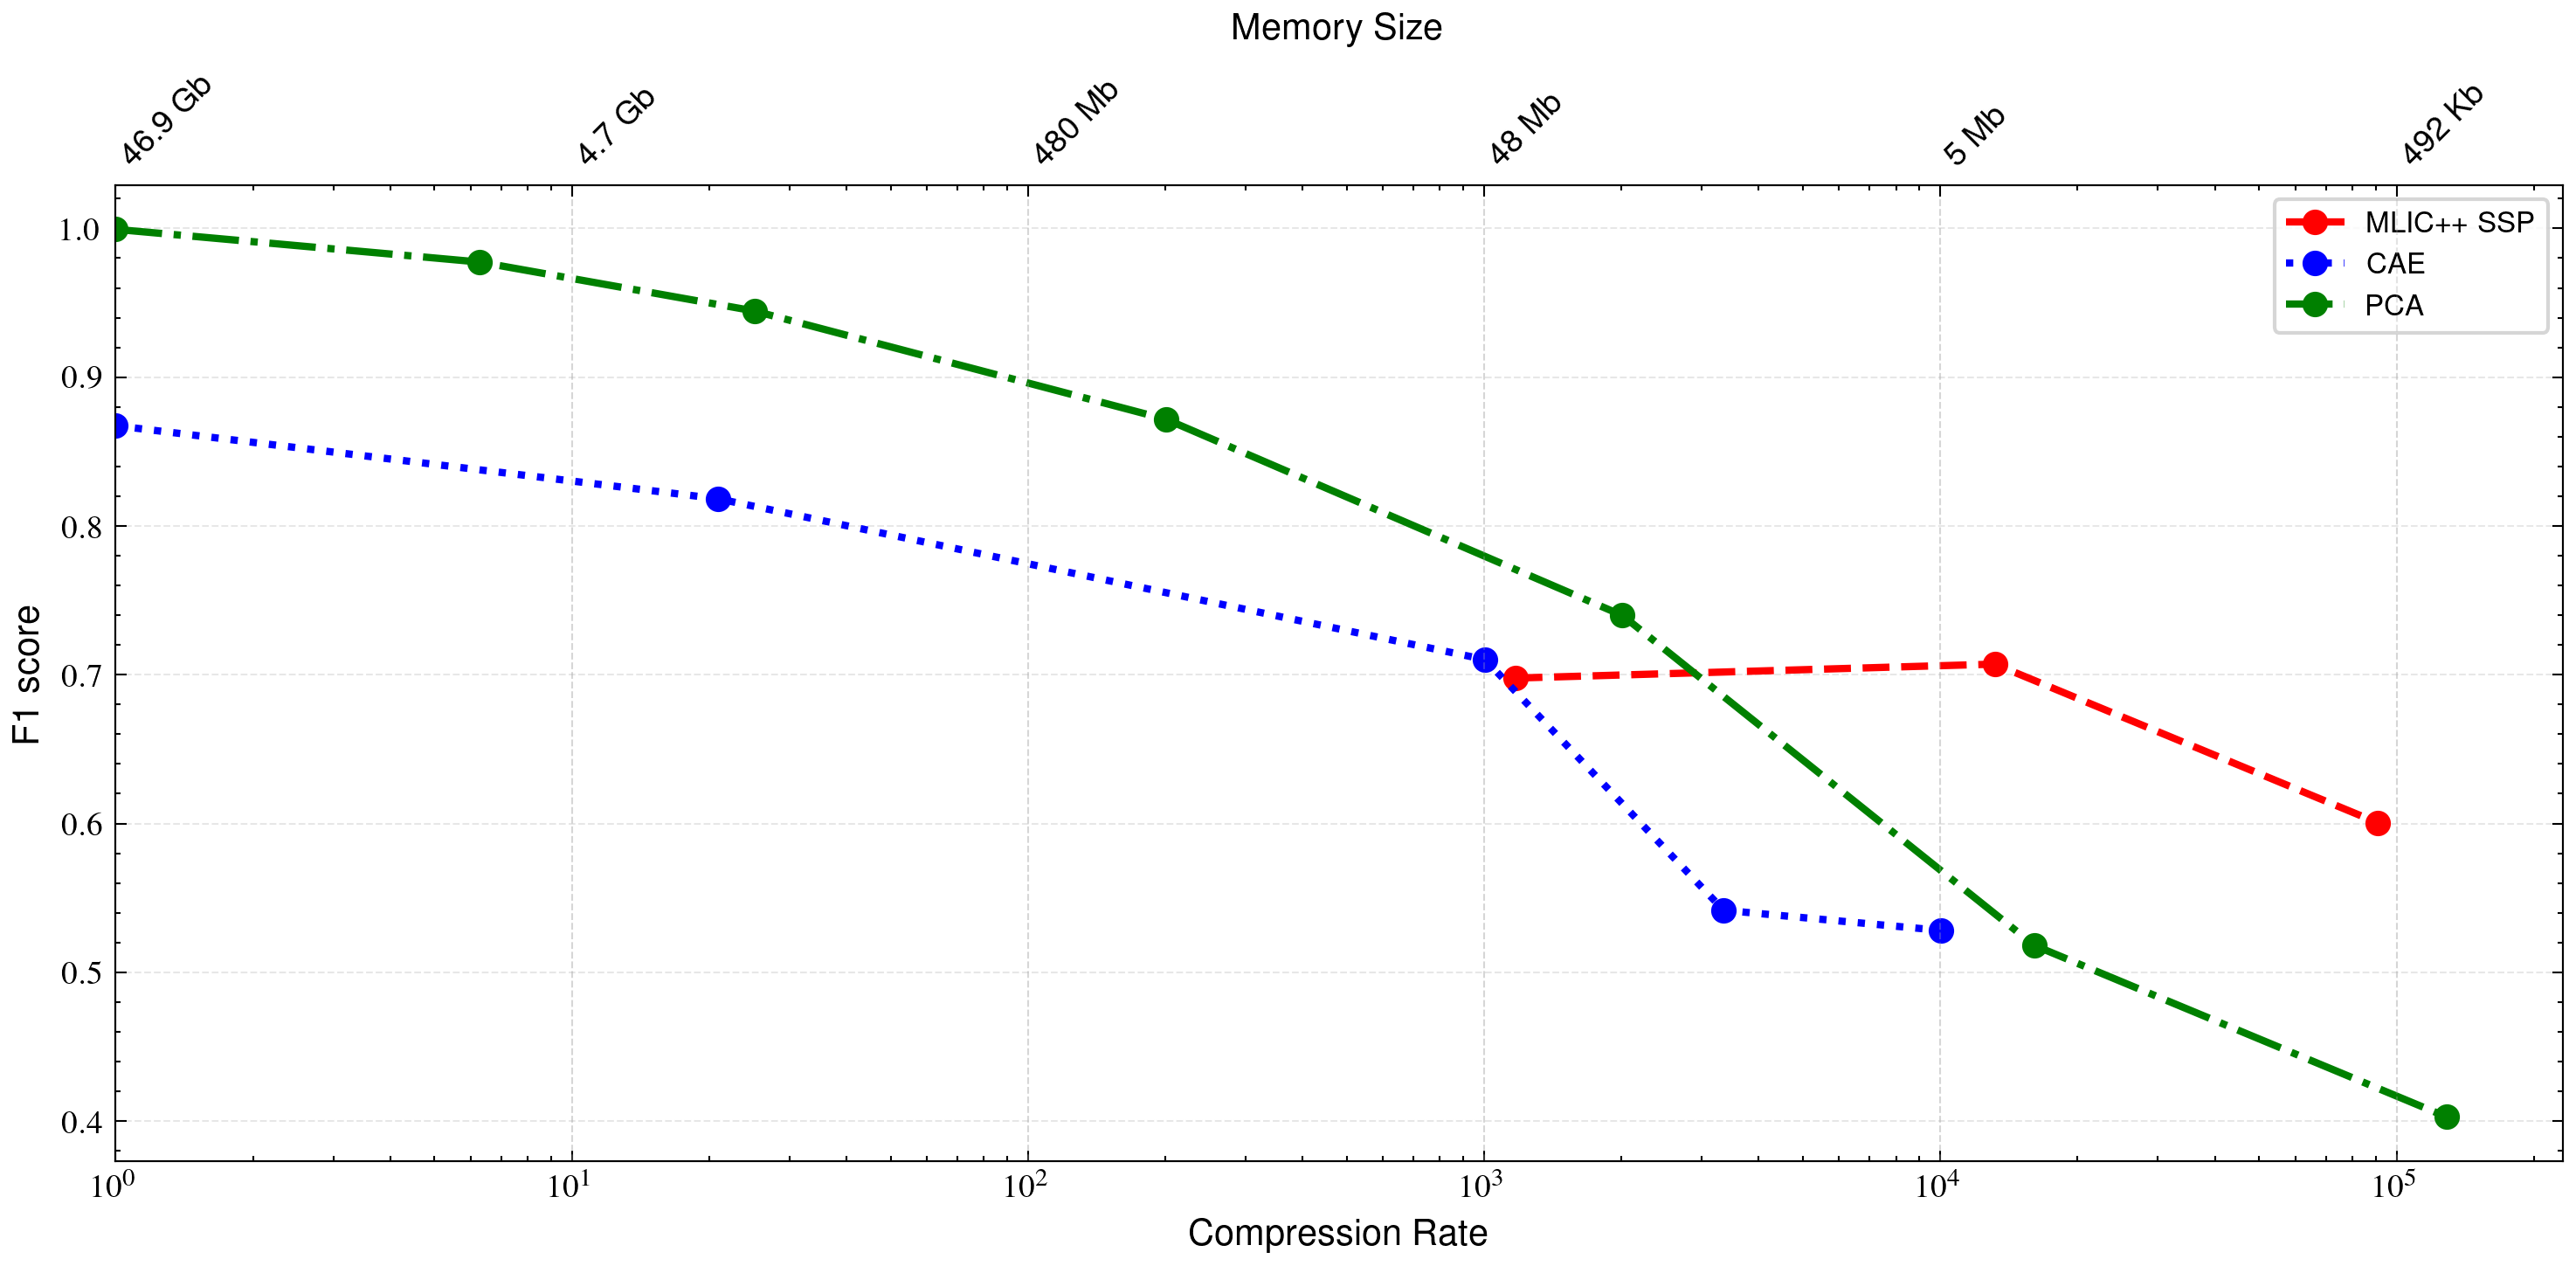

In [57]:

metric = "F1_score"
unit = {"RMSE":"(m/s)",
        "F1_score":"",
        "MS-SSIM": "",
        "R2_score": "",
        "ECS": "(m)"}

pareto_dir = {"RMSE":"min",
              "F1_score":"max",
              "MS-SSIM": "max",
              "R2_score": "max",
              "ECS": "min"}

ieee_rcparams = {
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica'],
        'font.size': 9,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 8,
        'figure.figsize': (8.5, 3.5),
        'figure.dpi': 300,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
        'lines.linewidth': 2,
        'patch.edgecolor': 'none',
        }

mpl.rcParams.update(ieee_rcparams)


colors = plt.rcParams['axes.prop_cycle'].by_key()['color']


# # Define IEEE colors: skip first (black), MLIC=red (2nd), CAE=blue, PCA=green
ieee_model_colors = {
'MLIC': colors[1],  # Red (2nd color in typical matplotlib)
'CAE': colors[2],   # Blue
'PCA': colors[3],   # Green
}

linestyle =   plt.rcParams['axes.prop_cycle'].by_key()['linestyle']

ieee_model_ls = {
'MLIC': linestyle[1],  # 
'CAE': linestyle[2],   # Dhed
'PCA': linestyle[3],   # 
}



fig, ax = plt.subplots(figsize=(10, 5))



pca_cr, pca_metric = filter_pareto_front(model_metrics_pca['PCA'], metric, direction=pareto_dir[metric])
pca_cr, pca_metric = filter_n_points_display(pca_cr,pca_metric,2e5,3)

cae_cr, cae_metric = filter_pareto_front_new(model_metrics_cae['CAE'],metric.lower(),type="SSP", direction=pareto_dir[metric])
cae_cr, cae_metric = filter_n_points_display(cae_cr,cae_metric,2e5,2)
        

#mlic_cr, mlic_metric = filter_pareto_front(model_metrics_mlic['MLIC++ SSP'], metric, direction=pareto_dir[metric])
mlic_cr = sorted(list(model_metrics_mlic['MLIC++ SSP'].keys()))
mlic_metric = [model_metrics_mlic['MLIC++ SSP'][cr][metric] for cr in mlic_cr]

plt.plot(mlic_cr, mlic_metric, marker='o', label='MLIC++ SSP', color=ieee_model_colors['MLIC'], linestyle=ieee_model_ls['MLIC'])
plt.plot(cae_cr, cae_metric, marker='o', label='CAE', color=ieee_model_colors['CAE'], linestyle=ieee_model_ls['CAE'])
plt.plot(pca_cr, pca_metric, marker='o', label='PCA', color=ieee_model_colors['PCA'], linestyle=ieee_model_ls['PCA'])




cr_ticks = np.array(ax.get_xticks())


# after all plotting on ax
ax.set_xscale("log")
ax.set_xlim(left=1)  # optional but usually needed for CR

# force matplotlib to compute final tick locations
ax.figure.canvas.draw()



# title = f"{metric.replace('_', ' ').replace('2', '²')} {unit[metric]} per Compression Rate"
# ax.set_title(title, pad=15)
ax.grid(True)
ax.set_xlabel("Compression Rate",)
ax.set_ylabel(f"{metric.replace('_', ' ').replace('2', '²')} {unit[metric]}")

ax.legend(loc='best',  frameon=True)

cr_ticks = np.array(ax.get_xticks(minor=False))
x0, x1 = ax.get_xlim()
valid = (cr_ticks >= 1) & (cr_ticks >= x0) & (cr_ticks <= x1)

ticks = cr_ticks[valid]
mem_labels = [cr_to_memory_size(t) for t in ticks]

# secondary axis
ax2 = ax.twiny()
ax2.set_xscale("log")
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(ticks)
ax2.set_xticklabels(mem_labels, rotation=45, ha="left")
ax2.set_xlabel("Memory Size",  labelpad=8)
ax2.tick_params(axis="x", which="major")

plt.savefig(f'/Odyssey/private/o23gauvr/code/articles/ICUA/imgs/{metric}_CR.pdf', bbox_inches='tight', dpi=300)

fig.tight_layout()
plt.show()


In [58]:
pca_cr, pca_metric

(array([1.000000e+00, 6.280000e+00, 2.512000e+01, 2.009600e+02,
        2.009600e+03, 1.607680e+04, 1.286144e+05]),
 array([0.9993671 , 0.977383  , 0.94450178, 0.87165126, 0.73985709,
        0.51804368, 0.40288884]))

In [59]:
cae_cr, cae_metric

(array([1.00000000e+00, 2.09333333e+01, 1.00480000e+03, 3.34933333e+03,
        1.00480000e+04]),
 array([0.86739472, 0.81827959, 0.71017716, 0.54171776, 0.52811267]))

In [61]:
mlic_cr = sorted(list(model_metrics_mlic["MLIC++ SSP"].keys()))
mlic_metric = [model_metrics_mlic["MLIC++ SSP"][cr]["F1_score"] for cr in mlic_cr]

mlic_cr, mlic_metric

([1171.4749215656268, 13167.767612842115, 91149.89137897044],
 [0.6977504305254882, 0.707135181521992, 0.6004203062776797])

In [60]:
cr_original, model_metrics_mlic_original["RGB_MLIC"][cr_original]['SSP']['f1_score']

(1388.7805224166716, 0.5924105922238356)

/tmp/ipykernel_713107/130497007.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


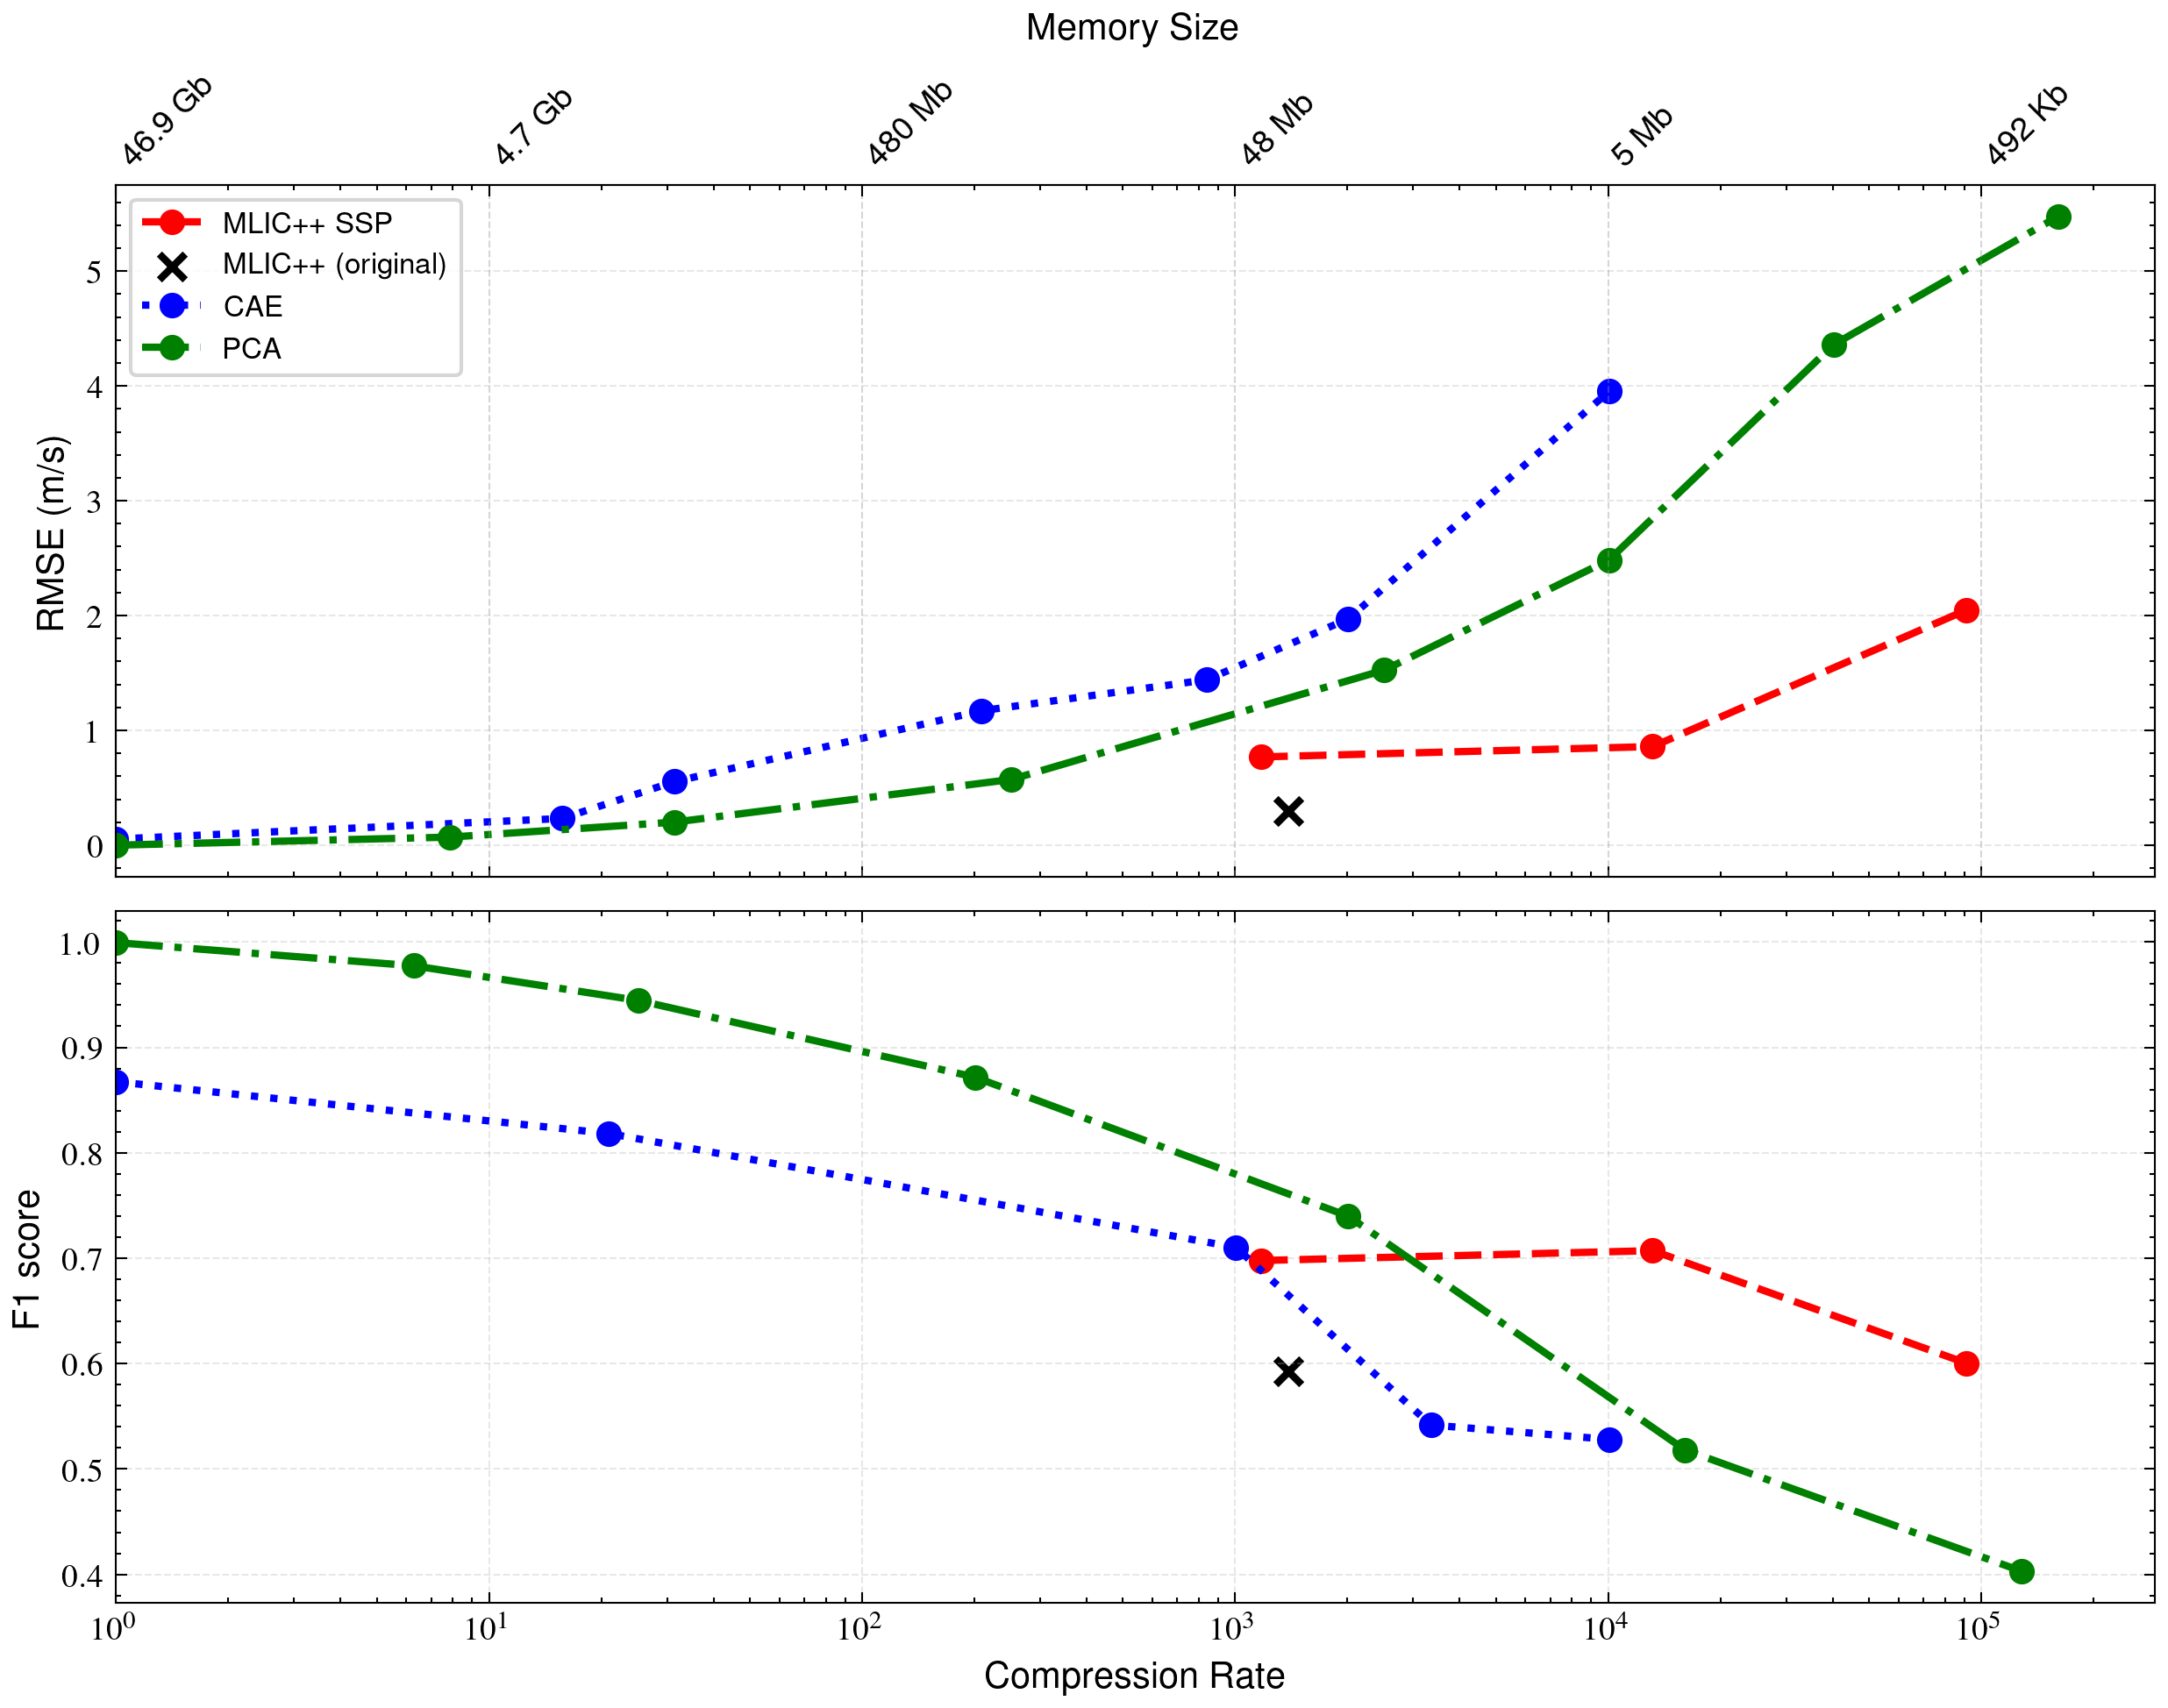

In [39]:
# Metrics to plot (top then bottom)
metrics = [
    ("RMSE", "(m/s)", "min"),
    ("F1_score", "", "max"),
]

cr_original = list(model_metrics_mlic_original["RGB_MLIC"].keys())[0]

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(10, 7), sharex=True, gridspec_kw={"hspace": 0.05}
)

axes = [ax_top, ax_bot]

for (metric, unit, direction), ax in zip(metrics, axes):
    # PCA pareto
    pca_cr, pca_metric = filter_pareto_front(model_metrics_pca["PCA"], metric, direction=direction)
    pca_cr, pca_metric = filter_n_points_display(pca_cr, pca_metric, 2e5, 3)

    cae_cr, cae_metric = filter_pareto_front_new(model_metrics_cae['CAE'],metric.lower(),type="SSP", direction=pareto_dir[metric])
    cae_cr, cae_metric = filter_n_points_display(cae_cr,cae_metric,2e5,2)

    # MLIC curve
    mlic_cr = sorted(list(model_metrics_mlic["MLIC++ SSP"].keys()))
    mlic_metric = [model_metrics_mlic["MLIC++ SSP"][cr][metric] for cr in mlic_cr]

    ax.plot(
        mlic_cr, mlic_metric, marker="o", label="MLIC++ SSP",
        color=ieee_model_colors["MLIC"], linestyle=ieee_model_ls["MLIC"]
    )

    ax.scatter( float(cr_original),
        model_metrics_mlic_original["RGB_MLIC"][cr_original]['SSP'][metric.lower()],
        marker="x", label="MLIC++ (original)", s=50)
    
    ax.plot(
        cae_cr, cae_metric, marker="o", label="CAE",
        color=ieee_model_colors["CAE"], linestyle=ieee_model_ls["CAE"]
    )

    ax.plot(
        pca_cr, pca_metric, marker="o", label="PCA",
        color=ieee_model_colors["PCA"], linestyle=ieee_model_ls["PCA"]
    )


    ax.set_ylabel(f"{metric.replace('_', ' ').replace('2', '²')} {unit}".rstrip())
    ax.grid(True)

# Shared x settings (apply once; sharex propagates)
ax_bot.set_xscale("log")
ax_bot.set_xlim(left=1)

# Only bottom subplot shows CR xlabel
ax_bot.set_xlabel("Compression Rate")
ax_top.tick_params(axis="x", which="both", labelbottom=False)

# Legend (pick one place)
ax_top.legend(loc="best", frameon=True)

# ---- Top axis on TOP subplot: Memory Size ----
# Force tick computation after scaling/limits/plots
fig.canvas.draw()

cr_ticks = np.array(ax_bot.get_xticks(minor=False))
x0, x1 = ax_bot.get_xlim()
valid = (cr_ticks >= 1) & (cr_ticks >= x0) & (cr_ticks <= x1)
ticks = cr_ticks[valid]
mem_labels = [cr_to_memory_size(t) for t in ticks]

ax_top_mem = ax_top.twiny()
ax_top_mem.set_xscale("log")
ax_top_mem.set_xlim(ax_top.get_xlim())
ax_top_mem.set_xticks(ticks)
ax_top_mem.set_xticklabels(mem_labels, rotation=45, ha="left")
ax_top_mem.set_xlabel("Memory Size", labelpad=8)

plt.savefig("/Odyssey/private/o23gauvr/code/articles/ICUA/imgs/RMSE_F1_CR.pdf",
            bbox_inches="tight", dpi=300)
fig.tight_layout()
plt.show()

## Profiles

In [30]:
cr_target = 10000
mlic_k = find_closest_key(list(data_dict_mlic['MLIC++ SSP'].keys()), cr_target)
mlic_data = data_dict_mlic['MLIC++ SSP'][mlic_k]
mlic_prof = mlic_data['selected']['t_lat_lon'][-1]

cae_k = find_closest_key(list(data_dict_cae['CAE'].keys()), cr_target)
cae_data = data_dict_cae['CAE'][cae_k]
cae_prof = cae_data['selected']['t_lat_lon'][-1]

pca_k = find_closest_key(list(data_dict_pca['PCA'].keys()), cr_target)
pca_data = data_dict_pca['PCA'][pca_k]
pca_prof = pca_data['selected']['t_lat_lon'][-1]

truth_prof = mlic_data['selected']['t_lat_lon'][1]

depth = dm.depth_array



KeyError: 'selected'

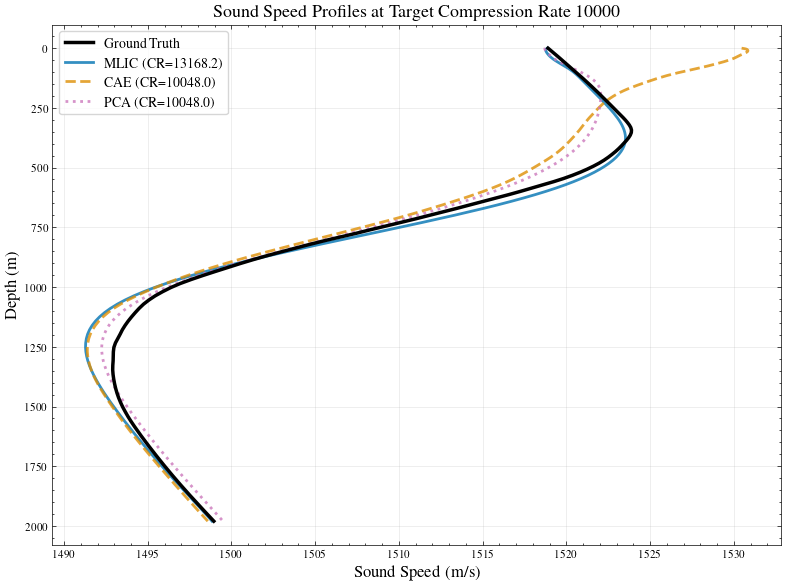

In [ ]:
# Plot profiles at compression rate
model_colors = {
    'MLIC': '#0173B2',  # Blue
    'CAE': '#DE8F05',   # Orange
    'PCA': '#CC78BC',   # Purple
}

fig, ax = plt.subplots(figsize=(8, 6))

# Plot truth profile
ax.plot(truth_prof, depth, 'k-', linewidth=2.5, label='Ground Truth', zorder=5)

# Plot model profiles
ax.plot(mlic_prof, depth, linewidth=2, label=f'MLIC (CR={mlic_k:.1f})', 
        color=model_colors['MLIC'], alpha=0.8)
ax.plot(cae_prof, depth, linewidth=2, label=f'CAE (CR={cae_k:.1f})', 
        color=model_colors['CAE'], alpha=0.8)
ax.plot(pca_prof, depth, linewidth=2, label=f'PCA (CR={pca_k:.1f})', 
        color=model_colors['PCA'], alpha=0.8)

# Formatting
ax.set_ylabel('Depth (m)', fontsize=12)
ax.set_xlabel('Sound Speed (m/s)', fontsize=12)
ax.set_title(f'Sound Speed Profiles at Target Compression Rate {cr_target}', fontsize=13, fontweight='bold')
ax.invert_yaxis()  # Depth increases downward
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10, frameon=True)

plt.tight_layout()
plt.show()


# generate models

In [62]:
crop_idx=20

In [63]:
cr_target = 1000
#ckpt_file = Path("/Odyssey/private/o23gauvr/code/MLIC/experiments/test_enatl_natl_mse/fixed_weight_loss_64_96_1.0_CR_10000.0_enatl_natl__mean_std/20260402_154931/checkpoints/best_checkpoint_bpp_loss.pth.tar")
ckpt_file_mlic = Path("/Odyssey/private/o23gauvr/code/FASCINATION/outputs/remote/outputs/ICUA/MLIC/fixed_weight_loss_64_96_1.0_CR_1000.0_enatl_natl__mean_std/20260407_004827/checkpoints/best_checkpoint_rmse.pth.tar")
ckpt_file_cae = Path("/Odyssey/private/o23gauvr/code/FASCINATION/outputs/remote/outputs/eusipco/AE/pred_1_grad_0_max_pos_0_max_value_0_fft_0_weighted_1_inflection_pos_0_inflection_value_0/dense_True/pooling_Avg_on_dim_dense/channels_[5000, 3000, 1000, 10]/upsample_mode_trilinear/linear_layer_False/cr_100000/1_conv_per_layer/padding_cubic/interp_size_5/final_upsample_upsample/act_fn_None/use_final_act_fn_False/lr_0.001/normalization_mean_std_along_depth/manage_nan_supress_with_max_depth/2026-02-13_12-43/checkpoints/best_checkpoint_rmse.pth.tar")



In [64]:

ssp_truth_da = dm.test_ds.input
depth_array = ssp_truth_da.z.values
dm_test_norm = ssp_truth_da.attrs['norm_stats']
season_idx = dm.test_ds.input.season_idx
sst_test_norm  = dm.test_ds.input.attrs['sst'].data

ssp_truth_da  = unorm_ssp_arr_3D(ssp_truth_da, dm_test_norm)
ssp_truth = ssp_truth_da.values.astype(np.float32)


In [65]:
cfg = parse_experiment_config(ckpt_file_mlic)
N = cfg.get('N', 192)
M = cfg.get('M', 320)
ssp_config = Config({
    'N': N, 'M': M, 'slice_num': cfg.get('slice_num', 10),
    'context_window': cfg.get('context_window', 5), 'act': cfg.get('act', nn.GELU),
    'in_channels': cfg.get('in_channels', 157), 'out_channels': cfg.get('in_channels', 157), 
    "add_seasons": cfg.get("add_seasons", {"use": False, "mode": None}),
    "add_sst": cfg.get("add_sst", False)
})



net = MLICPlusPlus(config=ssp_config).eval().to(device)
ck = torch.load(ckpt_file_mlic, map_location=device)

net.load_state_dict(ck['state_dict'])


test_norm_mlic = ck.get('train_norm_stats', None)

#test_norm_method =   #test_norm['method']
test_norm_mlic['method'] = ck.get('train_norm_stats', None)['method']
#test_norm_method = "mean_std" #"mean_std_along_depth" #"mean_std"


if test_norm_mlic['method'] == "min_max":
    x_min = test_norm_mlic["params"]["x_min"].astype(ssp_truth.dtype)
    x_max = test_norm_mlic["params"]["x_max"].astype(ssp_truth.dtype)    
    ssp_truth_tens = (ssp_truth - x_min) / (x_max - x_min)
elif test_norm_mlic['method'] == "mean_std":
    mean = test_norm_mlic['params']["mean"].astype(ssp_truth.dtype)
    std = test_norm_mlic['params']["std"].astype(ssp_truth.dtype)
    ssp_truth_tens = (ssp_truth - mean) / std
elif test_norm_mlic['method'] == "mean_std_along_depth":
    mean = test_norm_mlic['params']["mean_along_depth"].astype(ssp_truth.dtype)
    std = test_norm_mlic['params']["std_along_depth"].astype(ssp_truth.dtype)
    ssp_truth_tens = (ssp_truth - mean) / std


        
ssp_truth_tens = torch.tensor(ssp_truth_tens).to(device=device, dtype=getattr(torch,dm.dtype_str))
with torch.no_grad():
    rv_batch = net(ssp_truth_tens, season_idx, sst_test_norm)

ssp_ae_mlic = rv_batch['x_hat'].detach().cpu().numpy()

ssp_ae_mlic = unorm_ssp_arr_3D(ssp_ae_mlic, test_norm_mlic)
#ssp_truth = unorm_ssp_arr_3D(ssp_truth, test_norm)

bits = compute_total_bits(rv_batch)
total_original_bits = rv_batch['x_hat'].numel() * rv_batch['x_hat'].element_size() * 8

cr = total_original_bits / bits

ssp_ae_mlic_da = ssp_truth_da.copy(data=ssp_ae_mlic)


ssp_ae_mlic_da = ssp_ae_mlic_da.isel(lat=slice(crop_idx,-crop_idx),lon=slice(crop_idx,-crop_idx))

b, a = butter(N=2, Wn=0.1, btype='low', analog=False)
ssp_ae_mlic_da[:] = filtfilt(b, a, ssp_ae_mlic_da.data, axis=1).astype(ssp_ae_mlic_da.dtype)

ssp_ae_mlic = ssp_ae_mlic_da.values.astype(np.float32)


/Odyssey/private/o23gauvr/miniforge3/envs/fsc/lib/python3.11/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1720538435607/work/aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/tmp/ipykernel_713107/4142440197.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mod

In [66]:
cfg = get_cfg_from_ckpt_path(str(ckpt_file_cae), pprint=False)
ck = torch.load(ckpt_file_cae, map_location=device)
test_norm_cae = ck.get('norm_stats', None)
if test_norm_cae['method'] == "min_max":
    x_min = test_norm_cae["params"]["x_min"].astype(ssp_truth.dtype)
    x_max = test_norm_cae["params"]["x_max"].astype(ssp_truth.dtype)    
    ssp_truth_tens = (ssp_truth - x_min) / (x_max - x_min)
elif test_norm_cae['method'] == "mean_std":
    mean = test_norm_cae["params"]["mean"].astype(ssp_truth.dtype)
    std = test_norm_cae["params"]["std"].astype(ssp_truth.dtype)
    ssp_truth_tens = (ssp_truth - mean) / std
elif test_norm_cae['method'] == "mean_std_along_depth":
    mean = test_norm_cae["params"]["mean_along_depth"].astype(ssp_truth.dtype)
    std = test_norm_cae["params"]["std_along_depth"].astype(ssp_truth.dtype)
    ssp_truth_tens = (ssp_truth - mean) / std


ssp_truth_tens = torch.tensor(ssp_truth_tens).to(device=device, dtype=getattr(torch,dm.dtype_str))
lit_model = load_model(str(ckpt_file_cae), dm, ssp_truth_tens, verbose=False)

# Process in batches to avoid OOM
batch_size = 4  # Adjust based on GPU memory
print(f"Processing {ssp_truth_tens.shape[0]} samples in batches of {batch_size}...")
ssp_ae_cae = process_model_in_batches(lit_model, ssp_truth_tens, batch_size=batch_size, dim=0, device=device)
print(f"✓ Processing complete. Output shape: {ssp_ae_cae.shape}")

ssp_ae_cae = unorm_ssp_arr_3D(ssp_ae_cae, test_norm_cae)
ssp_ae_cae_da = ssp_truth_da.copy(data=ssp_ae_cae)

cr = lit_model.model_AE.cr if hasattr(lit_model.model_AE, 'cr') else 1.0
bpe = lit_model.model_AE.bpe if hasattr(lit_model.model_AE, 'bpe') else 0.0


ssp_ae_cae_da = ssp_ae_cae_da.isel(lat=slice(crop_idx,-crop_idx),lon=slice(crop_idx,-crop_idx))

b, a = butter(N=2, Wn=0.1, btype='low', analog=False)
ssp_ae_cae_da[:] = filtfilt(b, a, ssp_ae_cae_da.data, axis=1).astype(ssp_ae_cae_da.dtype)

ssp_ae_cae = ssp_ae_cae_da.values.astype(np.float32)

/tmp/ipykernel_713107/1153950881.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ck = torch.load(ckpt_file_cae, map_location=device)
/Odyssey/private/o23gauvr/miniforge3

Processing 164 samples in batches of 4...


Processing batches: 100%|██████████| 41/41 [00:04<00:00,  8.94it/s]


✓ Processing complete. Output shape: (164, 157, 192, 256)


In [67]:
n_components = 10
n_layer_pooling = 3
cr = 4**n_layer_pooling*ssp_truth.shape[1]/n_components 
pca = PCA(n_components=n_components, svd_solver='randomized', random_state=42)
train_ssp_unnorm = unorm_ssp_arr_3D(dm.train_ds.input.data.copy(), dm.train_ds.input.attrs['norm_stats'])
pca.fit(train_ssp_unnorm.transpose(0,2,3,1).reshape(-1, train_ssp_unnorm.shape[1]))
pca_ae = pca.transform(ssp_truth.transpose(0,2,3,1).reshape(-1, ssp_truth.shape[1]))
ssp_ae_pca = apply_pooling_upsample_to_pca(
    pca_ae,
    ssp_truth_shape=ssp_truth.shape,
    n_layer_pooling=n_layer_pooling,
)
ssp_ae_pca = pca.inverse_transform(ssp_ae_pca).reshape(ssp_truth.shape[0], ssp_truth.shape[2], ssp_truth.shape[3], ssp_truth.shape[1]).transpose(0,3,1,2)
ssp_ae_pca_da = ssp_truth_da.copy(data=ssp_ae_pca).astype(np.float32)

ssp_ae_pca_da = ssp_ae_pca_da.isel(lat=slice(crop_idx,-crop_idx),lon=slice(crop_idx,-crop_idx))

In [68]:
ssp_truth_da = ssp_truth_da.isel(lat=slice(crop_idx,-crop_idx),lon=slice(crop_idx,-crop_idx))


In [69]:
rmse_pca_da = np.sqrt(((ssp_ae_pca_da - ssp_truth_da) ** 2).mean(dim="z", skipna=True))

In [70]:
rmse_pca_da.shape

(164, 152, 216)

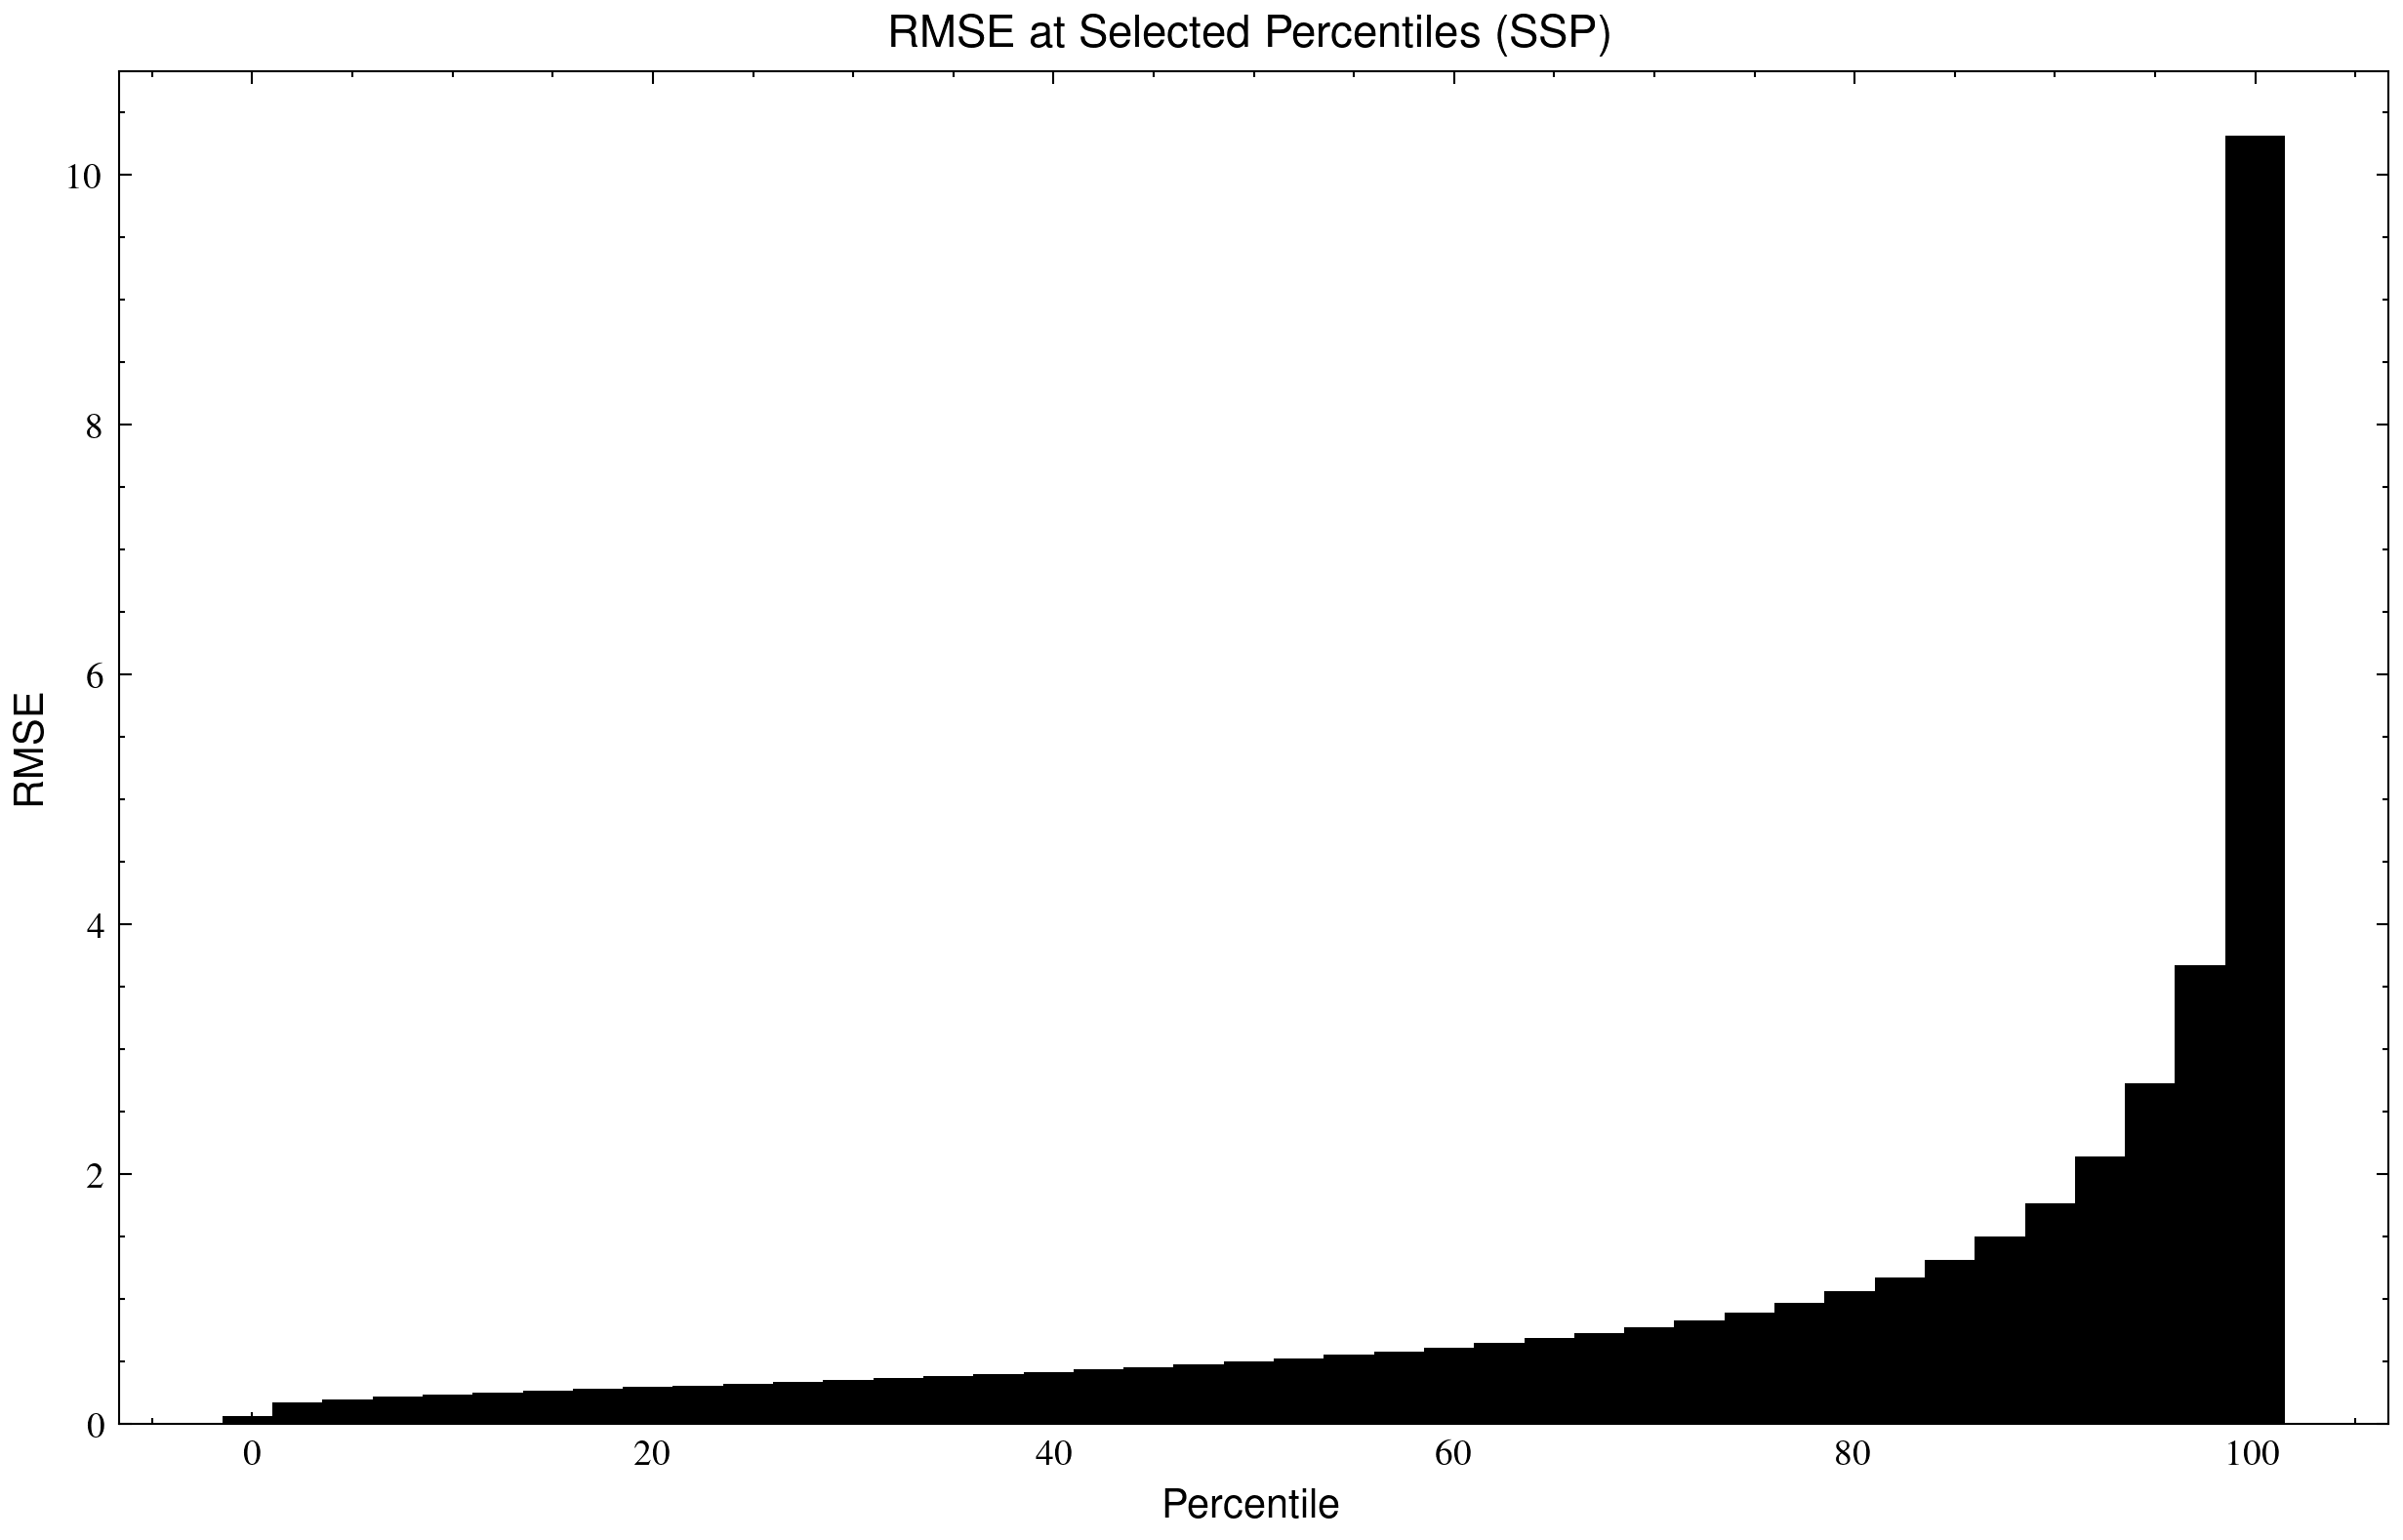

,time,lat,lon,rmse_value,percentile
0,13,37,158,0.062826,0.0
1,8,145,142,0.171762,2.5
2,80,24,119,0.197158,5.0
3,0,62,86,0.216638,7.5
4,162,37,50,0.233604,10.0
5,40,79,155,0.249075,12.5
6,134,26,64,0.263814,15.0
7,110,28,133,0.278168,17.5
8,14,37,189,0.292199,20.0
9,39,19,32,0.306278,22.5


In [71]:
rmse_df_deciles = get_rmse_df_deciles(rmse_pca_da,  metric_type="SSP")
rmse_df_deciles

In [72]:
deciles = 35
t,lat,lon = rmse_df_deciles.iloc[deciles][['time','lat','lon']].astype(int)

In [73]:
truth_prof = ssp_truth_da.isel(time=t, lat=lat, lon=lon).values
mlic_prof = ssp_ae_mlic_da.isel(time=t, lat=lat, lon=lon).values
cae_prof = ssp_ae_cae_da.isel(time=t, lat=lat, lon=lon).values
pca_prof = ssp_ae_pca_da.isel(time=t, lat=lat, lon=lon).values



In [74]:
rmse_mlic = np.sqrt(np.nanmean((truth_prof - mlic_prof) ** 2))
rmse_cae = np.sqrt(np.nanmean((truth_prof - cae_prof) ** 2))
rmse_pca = np.sqrt(np.nanmean((truth_prof - pca_prof) ** 2))

NameError: name 'depth' is not defined

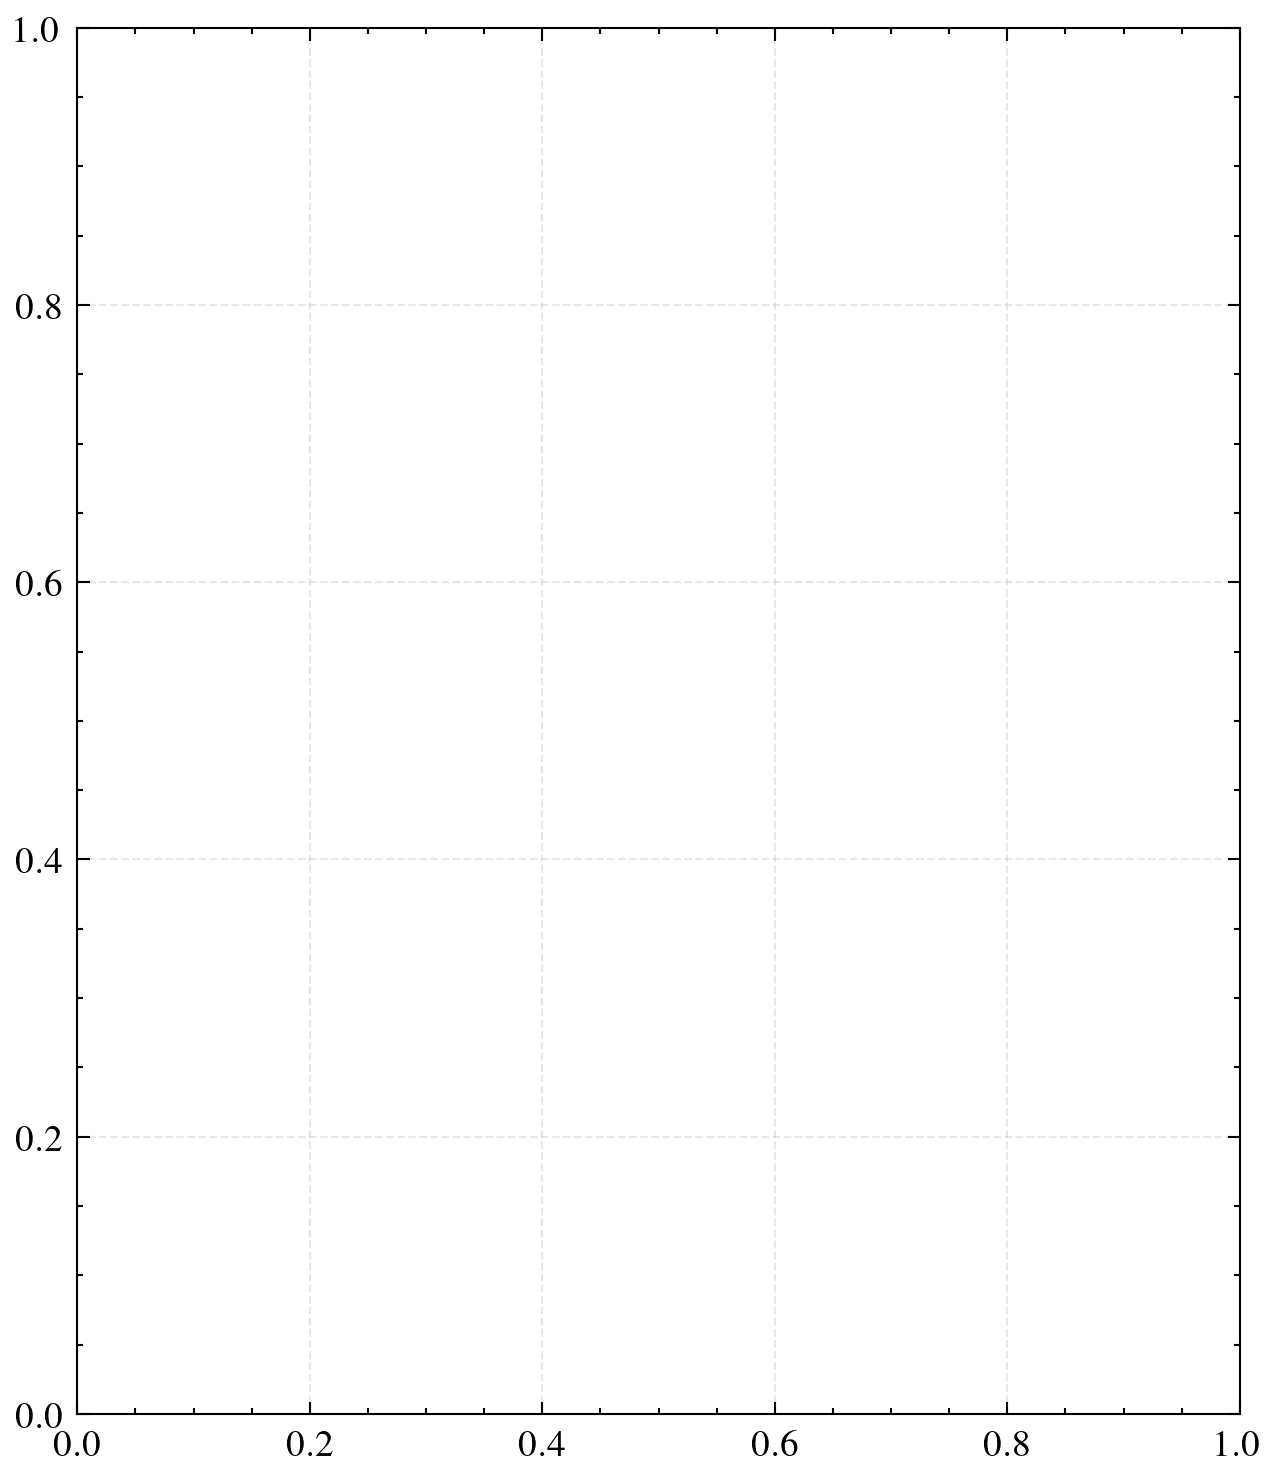

In [75]:
# Plot profiles at compression rate
# model_colors = {
#     'MLIC': '#0173B2',  # Blue
#     'CAE': '#DE8F05',   # Orange
#     'PCA': '#CC78BC',   # Purple
# }

fig, ax = plt.subplots(figsize=(5, 6))

# Plot truth profile
ax.plot(truth_prof, depth, '-', linewidth=2.5, label='Ground Truth', zorder=5)

# Plot model profiles
ax.plot(mlic_prof, depth, linewidth=2, label=f'MLIC (RMSE={rmse_mlic:.1f})', 
         alpha=0.8) #color=model_colors['MLIC']
ax.plot(cae_prof, depth, linewidth=2, label=f'CAE (RMSE={rmse_cae:.1f})', 
         alpha=0.8) #color=model_colors['CAE'],
ax.plot(pca_prof, depth, linewidth=2, label=f'PCA (RMSE={rmse_pca:.1f})', 
        alpha=0.8) #color=model_colors['PCA']

# Formatting
ax.set_ylabel('Depth (m)', fontsize=12)
ax.set_xlabel('Sound Speed (m/s)', fontsize=12)
ax.set_title(f'Sound Speed Profiles at Target Compression Rate {cr_target}', fontsize=13, fontweight='bold')
ax.invert_yaxis()  # Depth increases downward
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=10, frameon=True)

plt.savefig('/Odyssey/private/o23gauvr/code/articles/ICUA/imgs/profile_comparison.pdf', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()
